
Tolerance = 0.001
Jacobi iterations: 4 solution: [ 3.0000225  -2.50000266  6.99998104]
Gauss-Seidel iterations: 4 solution: [ 3.00000035 -2.50000004  6.99999999]


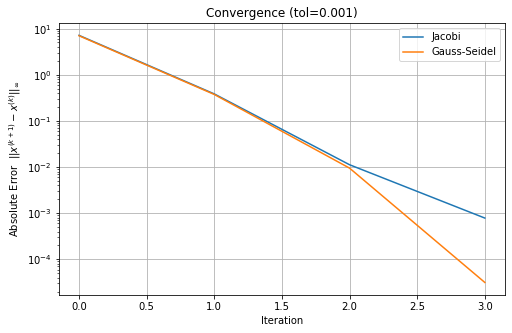


Tolerance = 1e-06
Jacobi iterations: 7 solution: [ 3.  -2.5  7. ]
Gauss-Seidel iterations: 5 solution: [ 3.  -2.5  7. ]


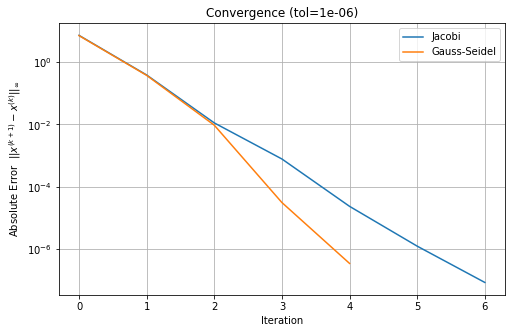


Tolerance = 1e-09
Jacobi iterations: 9 solution: [ 3.  -2.5  7. ]
Gauss-Seidel iterations: 7 solution: [ 3.  -2.5  7. ]


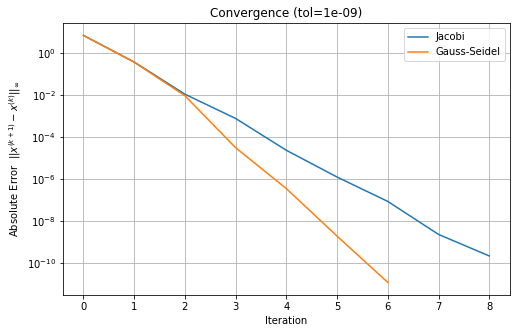

In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

A = np.array([
    [3.0,  -0.1, -0.2],
    [0.1,   7.0, -0.3],
    [0.3,  -0.2, 10.0]
], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)

x0 = np.array([0.0, 0.0, 0.0], dtype=float)


def jacobi(A, b, x0, tol=1e-6, max_iter=10000):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iter):
        x_new = np.zeros_like(x)

        for i in range(n):
            s = 0.0
            for j in range(n):
                if j != i:
                    s += A[i, j] * x[j]
            x_new[i] = (b[i] - s) / A[i, i]

        # absolute error between iterations
        err = np.linalg.norm(x_new - x, ord=np.inf)
        errors.append(err)

        if err < tol:
            return x_new, k + 1, errors

        x = x_new

    return x, max_iter, errors


def gauss_seidel(A, b, x0, tol=1e-6, max_iter=10000):
    n = len(b)
    x = x0.copy()
    errors = []

    for k in range(max_iter):
        x_old = x.copy()

        for i in range(n):
            # using updated values
            s1 = 0.0
            for j in range(i):
                s1 += A[i, j] * x[j]

            s2 = 0.0
            for j in range(i + 1, n):
                s2 += A[i, j] * x_old[j]

            x[i] = (b[i] - s1 - s2) / A[i, i]

        # absolute error between iterations (full sweep)
        err = np.linalg.norm(x - x_old, ord=np.inf)
        errors.append(err)

        if err < tol:
            return x, k + 1, errors

    return x, max_iter, errors


tolerances = [1e-3, 1e-6, 1e-9]

for tol in tolerances:
    x_j, it_j, err_j = jacobi(A, b, x0, tol=tol, max_iter=10000)
    x_gs, it_gs, err_gs = gauss_seidel(A, b, x0, tol=tol, max_iter=10000)

    print(f"\nTolerance = {tol:g}")
    print("Jacobi iterations:", it_j, "solution:", x_j)
    print("Gauss-Seidel iterations:", it_gs, "solution:", x_gs)

    plt.figure(figsize=(8, 5))
    plt.plot(err_j, label="Jacobi")
    plt.plot(err_gs, label="Gauss-Seidel")
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel(r"Absolute Error  $||x^{(k+1)} - x^{(k)}||_\infty$")
    plt.title(f"Convergence (tol={tol:g})")
    plt.grid(True)
    plt.legend()
    plt.show()

    
# AI USAGE DISCLOSURE:
# I used AI to double check my Python syntax and confirm the correct Jacobi and Gauss–Seidel
# iteration usage was made. I especially used it to help with the convergence plots.
# The method and equations still came from the lecture notes.
#
# AI Tool Used: ChatGPT 
# AI Prompt Used:
# "Help write Jacobi and Gauss-Seidel methods in Python for a 3x3 system,
# run them for tolerances 1e-3, 1e-6, 1e-9 with x0=[0,0,0], track the absolute error
# between iterations, and plot the convergence."
